In [2]:
pwd

'/home/sokoi0a/_research_projects/2024_p-LORA-experiments'

# p-LoRA project

In [2]:
import scipy
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import copy
from scipy.linalg import qr
from sklearn.random_projection import GaussianRandomProjection

In [7]:
np.ones(6, dtype=np.float64)

array([1., 1., 1., 1., 1., 1.])

In [4]:
%%bash
find rac_lora_mnist/outs -type f -name "*.out" | while read -r file; do
  echo -e "\n----------------------------"
  echo "File: $(basename "$file")"
  echo ""
  cat "$file"
  echo ""
done



----------------------------
File: merge-1_prob-0,01_zero-0_gauss-1_det-0_A1_B0.out

Experiment number 7/132
Running with: {'rank': 1, 'merge_frequency': 1, 'use_stochastic': True, 'prob': 0.01, 'init_train_zero': False, 'gaussian_resample': True, 'deterministic_init': False, 'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian'}
Final test accuracy = 0.4805595576763153
---------------


----------------------------
File: merge-1_prob-0,01_zero-0_gauss-1_det-1_A0_B1.out

Experiment number 9/132
Running with: {'rank': 1, 'merge_frequency': 1, 'use_stochastic': True, 'prob': 0.01, 'init_train_zero': False, 'gaussian_resample': True, 'deterministic_init': True, 'train_A': False, 'train_B': True, 'init_method_A': 'gaussian', 'init_method_B': 'zero'}
Final test accuracy = 0.20592470467090607
---------------


----------------------------
File: merge-1_prob-0,01_zero-1_gauss-0_det-1_A1_B0.out

Experiment number 5/132
Running with: {'rank': 1, 'merge_frequen

In [3]:
%%bash
find rac_lora_mnist -type f -name "*.py" | while read -r file; do
  echo -e "\n----------------------------"
  echo "File: $(basename "$file")"
  echo ""
  cat "$file"
  echo ""
done



----------------------------
File: base_mnist.py

import lightning as L
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision.datasets import MNIST
from torchvision import transforms
from torchmetrics import Accuracy

class BaseMNIST(L.LightningModule):
    def __init__(self, config):
        """Initialize the base MNIST model.
        
        Parameters
        ----------
        config : Config
            Configuration dataclass containing model hyperparameters
            
        Attributes
        ----------
        class_names : list[int]
            List of class indices to use (default: [0, 1, 2, 3, 4])
        min_class : int
            Minimum class index (used for label adjustment)
        num_classes : int
            Number of classes in the dataset
        dims : tuple
            Input dimensions (channels, height, width)
  

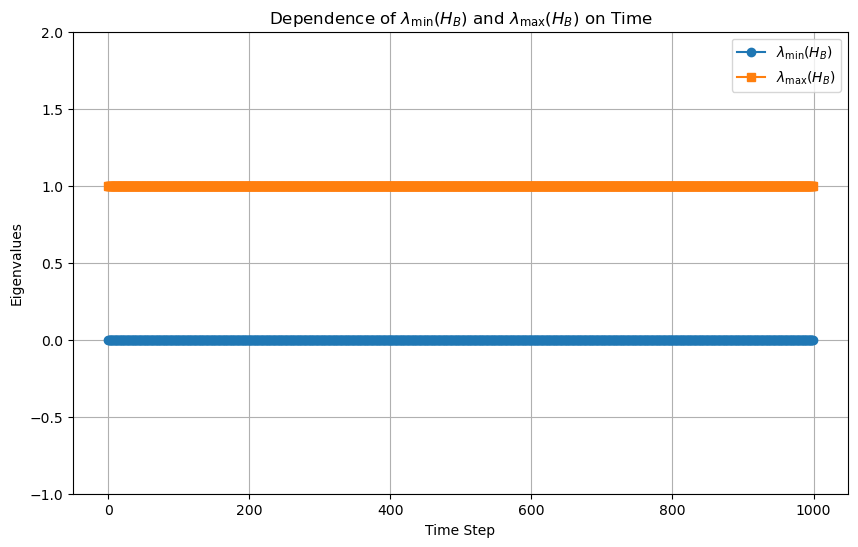

In [11]:
def compute_projection_matrix(B_S):
    """
    Compute the projection matrix H_B = B_S @ ((B_S^T @ B_S)^†) @ B_S^T.
    
    Parameters:
        B_S (np.ndarray): Input matrix of shape (n, r).
        
    Returns:
        H_B (np.ndarray): Projection matrix.
    """
    B_S_T = B_S.T
    pseudo_inverse = np.linalg.pinv(B_S_T@B_S)
    H_B = B_S @ pseudo_inverse @ B_S_T
    return H_B

# Parameters
n, r = 100, 4  # Dimensions of the Gaussian matrix
time_steps = 1000  # Number of discrete time steps

# Lists to store eigenvalues
lamin_values = []
lamax_values = []

# Simulation
for _ in range(time_steps):
    # Sample B_S as a Gaussian matrix
    B_S = np.random.randn(n, r)
    
    # Compute projection matrix
    H_B = compute_projection_matrix(B_S)
    
    # Compute eigenvalues
    eigenvalues = np.linalg.eigvalsh(H_B)
    lamin_values.append(np.min(eigenvalues))
    lamax_values.append(np.max(eigenvalues))
    
plt.figure(figsize=(10, 6))
plt.plot(range(time_steps), lamin_values, label=r'$\lambda_{\min}(H_B)$', marker='o')
plt.plot(range(time_steps), lamax_values, label=r'$\lambda_{\max}(H_B)$', marker='s')
plt.xlabel('Time Step')
plt.ylabel('Eigenvalues')
plt.title('Dependence of $\lambda_{\min}(H_B)$ and $\lambda_{\max}(H_B)$ on Time')
plt.ylim(-1, 2)  # Scale y-axis from 0 to 2
plt.legend()
plt.grid(True)
plt.show()

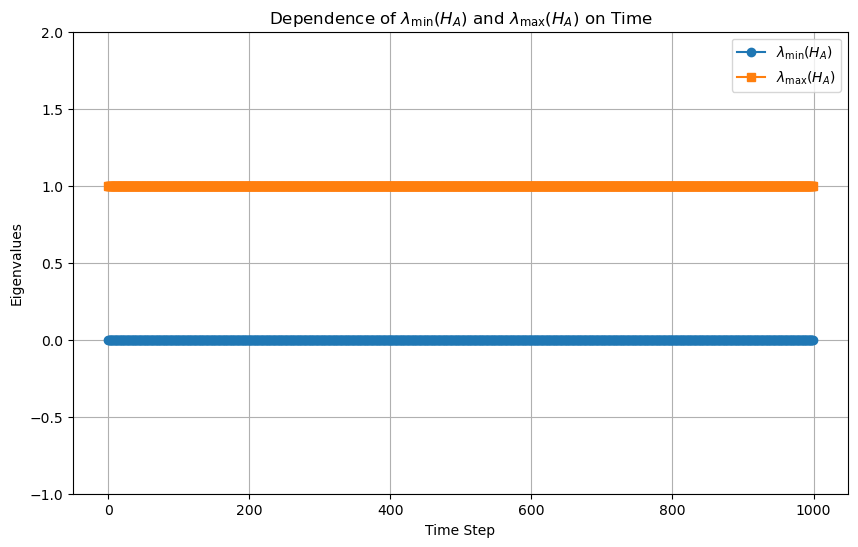

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def compute_projection_matrix_A(A):
    """
    Compute the projection matrix H_A = A^T @ ((A @ A^T)^†) @ A.
    
    Parameters:
        A (np.ndarray): Input matrix of shape (n, r).
        
    Returns:
        H_A (np.ndarray): Projection matrix.
    """
    A_T = A.T
    pseudo_inverse = np.linalg.pinv(A @ A_T)  # Compute the pseudo-inverse of A @ A^T
    H_A = A_T @ pseudo_inverse @ A
    return H_A

# Parameters
n, r = 100, 4  # Dimensions of A
time_steps = 1000  # Number of time steps

# Lists to store eigenvalues
lamin_values = []
lamax_values = []

# Simulation
for _ in range(time_steps):
    A = np.random.randn(r, n)  # Gaussian matrix
    H_A = compute_projection_matrix_A(A)
    eigenvalues = np.linalg.eigvalsh(H_A)
    lamin_values.append(np.min(eigenvalues))
    lamax_values.append(np.max(eigenvalues))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(time_steps), lamin_values, label=r'$\lambda_{\min}(H_A)$', marker='o')
plt.plot(range(time_steps), lamax_values, label=r'$\lambda_{\max}(H_A)$', marker='s')
plt.xlabel('Time Step')
plt.ylabel('Eigenvalues')
plt.title('Dependence of $\lambda_{\min}(H_A)$ and $\lambda_{\max}(H_A)$ on Time')
plt.ylim(-1, 2)  # Scale y-axis from 0 to 2
plt.legend()
plt.grid(True)
plt.show()


In [18]:
import numpy as np

def left_sketch_B(B):
    """
    Compute the projection matrix H_B = B @ ((B^T @ B)^†) @ B^T.
    """
    B_T = B.T
    pseudo_inverse = np.linalg.pinv(B_T @ B)
    H_B = B @ pseudo_inverse @ B_T
    return H_B

def right_sketch_A(A):
    """
    Compute the projection matrix H_A = A^T @ ((A @ A^T)^†) @ A.
    """
    A_T = A.T
    pseudo_inverse = np.linalg.pinv(A @ A.T)
    H_A = A_T @ pseudo_inverse @ A
    return H_A

def monte_carlo_estimation_lamin_fixed(n, r, num_trials):
    """
    Estimate lamin(E(H_B)) and lamin(E(H_A)) via Monte Carlo simulation.
    
    Parameters:
        n (int): Dimension of the space.
        r (int): Dimension of the Gaussian matrices.
        num_trials (int): Number of Monte Carlo trials.
        
    Returns:
        lamin_E_H_B (float): Estimated lamin(E(H_B)).
        lamin_E_H_A (float): Estimated lamin(E(H_A)).
    """
    H_B_sum = np.zeros((n, n))
    H_A_sum = np.zeros((n, n))

    for _ in range(num_trials):
        # Sample Gaussian matrices
        B_S = np.random.randn(n, r)
        A_S = np.random.randn(r, n)

        # Compute projection matrices
        H_B = compute_projection_matrix_B(B_S)
        H_A = compute_projection_matrix_A(A_S)

        # Accumulate the matrices
        H_B_sum += H_B
        H_A_sum += H_A

    # Compute the expectations of the matrices
    E_H_B = H_B_sum / num_trials
    E_H_A = H_A_sum / num_trials

    # Compute the minimum eigenvalues of the expectations
    lamin_E_H_B = np.min(np.linalg.eigvalsh(E_H_B))
    lamin_E_H_A = np.min(np.linalg.eigvalsh(E_H_A))

    return lamin_E_H_B, lamin_E_H_A

# Parameters
n = 100
r = 4
num_trials = 100_000

# Estimate lamin(E(H_B)) and lamin(E(H_A))
lamin_E_H_B_fixed, lamin_E_H_A_fixed = monte_carlo_estimation_lamin_fixed(n, r, num_trials)
lamin_E_H_B_fixed, lamin_E_H_A_fixed



(0.038792611415445696, 0.03873621027349607)

# Grisha's code

(4000, 100)
3000 100
mu_pret, L_pret
8.51093222578412e-06 0.00025130023973186065
mu_ft, L_ft
7.1401476273756825e-06 0.00026439730463816803


100%|██████████| 3000/3000 [00:00<00:00, 4348.64it/s]


100
10


100%|██████████| 3000/3000 [00:00<00:00, 7692.00it/s]


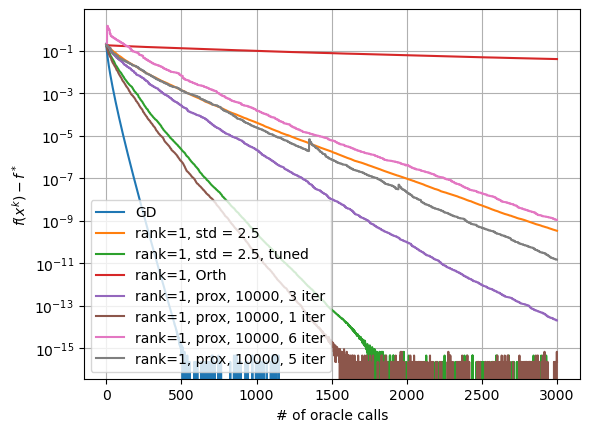

In [3]:
# test

# A,b = datasets.load_svmlight_file("abalone.txt")
A, b = datasets.make_regression(n_samples=4000, n_features=100, n_informative=100, bias=2.0, tail_strength=0.5, effective_rank=10 )
# , tail_strength=0.5
# print(A.shape)

# A = np.array(A.todense())
print(A.shape)
A_pretrained = np.array(A[0:3000])
b_pretrained = np.array(b[0:3000])

A_finetuned = np.array(A[3000:4000])
b_finetuned = np.array(b[3000:4000])

# A = np.array(A[0:4000])
# b = np.array(b[0:4000])
n_pret = A_pretrained.shape[0]
d_pret = A_pretrained.shape[1]

print(n_pret, d_pret)

n_ft = A_finetuned.shape[0]
d_ft = A_finetuned.shape[1]
# print(n,d)

# Setting the l2 regularizer 
 
lambda_2_pret = 0.0001 * np.max(np.linalg.eigvalsh(A_pretrained.T @ A_pretrained / n_pret))

# Calculating strong convexity and L-smoothness constants 

mu_pret = np.min(np.linalg.eigvalsh(A_pretrained.T @ A_pretrained / n_pret)) + lambda_2_pret

L_pret = np.max(np.linalg.eigvalsh(A_pretrained.T @ A_pretrained / n_pret)) + lambda_2_pret
print('mu_pret, L_pret')
print(mu_pret, L_pret)

# Calculating individual L_i - smoothness constants 

L_i_pret = np.diag(A_pretrained @ A_pretrained.T) + lambda_2_pret

# print(L_i[0])

# Calculating the optimal point (solution)

x_star_pret = np.linalg.inv(A_pretrained.T @ A_pretrained + n_pret * lambda_2_pret * np.eye(d_pret)) @ A_pretrained.T @ b_pretrained


def grad(x, idx):
    return A_pretrained[idx].T @ (A_pretrained[idx] @ x - b_pretrained[idx]) / len(idx) + lambda_2_pret * x

def func_value(x):
    return (1/(2*len(A_pretrained)))*(np.linalg.norm(A_pretrained@x-b_pretrained))**2+(lambda_2_pret/2)*np.linalg.norm(x)**2

def grad_full(x):
    return A_pretrained.T @ (A_pretrained @ x - b_pretrained) / n_pret + lambda_2_pret * x
def grad_us(x):
    idx = np.random.choice(list(range(n_pret)), size = 1, replace=True)
    return grad(x, idx)

def grad_is(x):
    idx = np.random.choice(list(range(n_pret)), size = 1, replace=True, p=L_i_pret / np.sum(L_i_pret))
    return grad(x, idx)

# Implementing full_batch centralized GD method

def gd(x_0, gamma, max_iter = 10000):
    x_k = np.copy(x_0)
    list_of_norms = [np.linalg.norm(x_k - x_star_pret) ** 2]
    list_of_points = [x_0]
    list_of_losses = [func_value(x_0) - func_value(x_star_pret)]
    for k in tqdm(range(int(max_iter))):
        x_k -= gamma * grad_full(x_k)
        list_of_norms.append(np.linalg.norm(x_k - x_star_pret) ** 2 )
        list_of_points.append(x_k)
        list_of_losses.append(func_value(x_k) - func_value(x_star_pret))

    return list_of_points, list_of_norms, list_of_losses

# list_of_points, list_of_norms, list_of_losses = gd(np.ones(d_pret), 1/L_pret, 300000)

# plt.plot(list_of_norms)
# plt.yscale('log')
# plt.savefig('test-test.pdf')









# ========================================================================

lambda_2_ft = 0.001*np.max(np.linalg.eigvalsh(A_finetuned.T @ A_finetuned / n_ft)) 

# Calculating strong convexity and L-smoothness constants 

mu_ft = np.min(np.linalg.eigvalsh(A_finetuned.T @ A_finetuned / n_ft)) + lambda_2_ft

L_ft = np.max(np.linalg.eigvalsh(A_finetuned.T @ A_finetuned / n_ft)) + lambda_2_ft
print('mu_ft, L_ft')
print(mu_ft, L_ft)

# Calculating individual L_i - smoothness constants 

L_i_ft = np.diag(A_finetuned @ A_finetuned.T) + lambda_2_ft

# print(L_i[0])

# Calculating the optimal point (solution)

x_star_ft = np.linalg.inv(A_finetuned.T @ A_finetuned + n_ft * lambda_2_ft * np.eye(d_ft)) @ A_finetuned.T @ b_finetuned

# print(np.reshape(x_star_ft, (2,4)))
# print(x_star_pret)

def grad_ft(x, idx):
    return A_finetuned[idx].T @ (A_finetuned[idx] @ x - b_finetuned[idx]) / len(idx) + lambda_2_ft * x

def func_value_ft(x):
    return (1/(2*len(A_finetuned)))*(np.linalg.norm(A_finetuned@x-b_finetuned))**2+(lambda_2_ft/2)*np.linalg.norm(x)**2

def grad_full_ft(x):
    return A_finetuned.T @ (A_finetuned @ x - b_finetuned) / n_ft + lambda_2_ft * x
def grad_us_ft(x):
    idx = np.random.choice(list(range(n_ft)), size = 1, replace=True)
    return grad_ft(x, idx)

def grad_is_ft(x):
    idx = np.random.choice(list(range(n_ft)), size = 1, replace=True, p=L_i_ft / np.sum(L_i_ft))
    return grad_ft(x, idx)

# ======================================================================================================

def ProxLora(W_0, alpha, inner_step_size, iter_max_sub, max_iter, gamma, rank, d_ft, d_mat_ft, mean, std, track=False):
    current_matrix = W_0
    d_mat_ft = current_matrix.shape[0]
    list_of_points_w = []
    
    for t in tqdm(range(max_iter)):
        W_k = copy.deepcopy(current_matrix)
        
        # print(k)
        
        S_k = np.random.normal(mean, std, size=(d_mat_ft, rank))
        current_Z = solve_subproblem(W_k, current_matrix, S_k, iter_max_sub, inner_step_size, gamma, rank, d_ft, d_mat_ft)
        W_k += S_k@current_Z
        current_matrix = current_matrix + alpha*(W_k - current_matrix)
        if track:
            for j in range(iter_max_sub):
                list_of_points_w.append(np.reshape(current_matrix, (d_ft,)))
        else:
            list_of_points_w.append(np.reshape(current_matrix, (d_ft,)))
        
        # list_of_points_w.append(np.reshape(current_matrix, (8,)))
        

    

    return list_of_points_w



def solve_subproblem(W_cur, W, S, iter_max_sub, step_size, gamma, rank, d_ft, d_mat_ft):
    Z_0 = np.zeros((rank, d_mat_ft))
    
    Z_cur = Z_0
    for j in range(iter_max_sub):
        delta = np.reshape(W_cur + S@Z_cur, (d_ft,))
        Z_cur = Z_cur - step_size* S.T @ (np.reshape(grad_full_ft(delta), (d_mat_ft, d_mat_ft)) + (1./gamma)*(W_cur+S@Z_cur - W))
    return Z_cur


    
  



def RandChain_Lora_Lin(W_0, alpha, step_size, max_iter, rank, d, d_mat, mean, std):
    current_matrix = W_0
    d_mat = current_matrix.shape[0]
    list_of_points_w = []
    list_of_values_w = []
    
    for t in tqdm(range(max_iter)):
        W_k = copy.deepcopy(current_matrix)
        S_k = np.random.normal(mean, std, size=(d_mat, rank))
        delta = np.reshape(W_k, (d,))
        W_k += -step_size * S_k @ np.linalg.inv(S_k.T @ S_k) @ S_k.T @ np.reshape(grad_full_ft(delta), (d_mat, d_mat))
        # for k in range(0, k_max):
        #     # print(k)
        #     list_of_points_w.append(np.reshape(current_matrix, (d,)))
        #     list_of_values_w.append(log_loss(np.reshape(current_matrix, (d,))))
        #     S_k = np.random.normal(mean, std, size=(d_mat, rank))
        #     current_Z = solve_subproblem(W_k, current_matrix, S_k, iter_max_sub, inner_step_size, gamma, rank, d, d_mat)
        #     W_k += S_k@current_Z
        current_matrix = current_matrix + alpha*(W_k - current_matrix)
        list_of_points_w.append(np.reshape(current_matrix, (d,)))
        list_of_values_w.append(func_value_ft(np.reshape(current_matrix, (d,))))
        # list_of_points_w.append(np.reshape(current_matrix, (8,)))
        

    

    return list_of_points_w, list_of_values_w


def RandChain_Lora_Lin_Orth(W_0, alpha, step_size, max_iter, rank, d, d_mat):
    current_matrix = W_0
    d_mat = current_matrix.shape[0]
    list_of_points_w = []
    list_of_values_w = []
    
    for t in tqdm(range(max_iter)):
        W_k = copy.deepcopy(current_matrix)
        Mat = np.random.rand(d_mat, d_mat)
        U, _, _ = np.linalg.svd(Mat)
        S_k = U[:, : rank]

        # S_k = np.random.normal(mean, std, size=(d_mat, rank))
        delta = np.reshape(W_k, (d,))
        W_k += -step_size * S_k @ np.linalg.inv(S_k.T @ S_k) @ S_k.T  @ np.reshape(grad_full_ft(delta), (d_mat, d_mat))
        # for k in range(0, k_max):
        #     # print(k)
        #     list_of_points_w.append(np.reshape(current_matrix, (d,)))
        #     list_of_values_w.append(log_loss(np.reshape(current_matrix, (d,))))
        #     S_k = np.random.normal(mean, std, size=(d_mat, rank))
        #     current_Z = solve_subproblem(W_k, current_matrix, S_k, iter_max_sub, inner_step_size, gamma, rank, d, d_mat)
        #     W_k += S_k@current_Z
        current_matrix = current_matrix + alpha*(W_k - current_matrix)
        list_of_points_w.append(np.reshape(current_matrix, (d,)))
        list_of_values_w.append(func_value_ft(np.reshape(current_matrix, (d,))))
        # list_of_points_w.append(np.reshape(current_matrix, (8,)))
        

    

    return list_of_points_w, list_of_values_w

def RandChain_Lora_Lin_Unifrom(W_0, alpha, step_size, max_iter, rank, d, d_mat):
    current_matrix = W_0
    d_mat = current_matrix.shape[0]
    list_of_points_w = []
    list_of_values_w = []
    
    for t in tqdm(range(max_iter)):
        W_k = copy.deepcopy(current_matrix)
        S_k = np.random.rand(d_mat, rank)
        # Mat = np.random.rand(d_mat, d_mat)
        # U, _, _ = np.linalg.svd(Mat)
        # S_k = U[:, : rank]
        H_t =  S_k @ np.linalg.inv(S_k.T @ S_k) @ S_k.T 
        # S_k = np.random.normal(mean, std, size=(d_mat, rank))
        delta = np.reshape(W_k, (d,))
        W_k += -step_size * H_t@(np.reshape(grad_full_ft(delta), (d_mat, d_mat)))
        # for k in range(0, k_max):
        #     # print(k)
        #     list_of_points_w.append(np.reshape(current_matrix, (d,)))
        #     list_of_values_w.append(log_loss(np.reshape(current_matrix, (d,))))
        #     S_k = np.random.normal(mean, std, size=(d_mat, rank))
        #     current_Z = solve_subproblem(W_k, current_matrix, S_k, iter_max_sub, inner_step_size, gamma, rank, d, d_mat)
        #     W_k += S_k@current_Z
        current_matrix = current_matrix + alpha*(W_k - current_matrix)
        list_of_points_w.append(np.reshape(current_matrix, (d,)))
        list_of_values_w.append(func_value_ft(np.reshape(current_matrix, (d,))))
        # list_of_points_w.append(np.reshape(current_matrix, (8,)))
        

    

    return list_of_points_w, list_of_values_w
# gamma = 1/n_ft

# list_of_z, Z_last = solve_subproblem(np.reshape(x_star_pret, (2,4)),
#                                     np.reshape(x_star_pret, (2,4)),
#                                     np.random.normal(1, 2.5, size=(2, 1)),
#                                     10000,
#                                     1/(1000*(L_ft+1./gamma)),
#                                     gamma)
# list_of_norms_z = []
# for z in list_of_z:
#     list_of_norms_z.append(func_value_ft(np.reshape(np.random.normal(1, 2.5, size=(2, 1))@z, (8,))))

# plt.plot(list_of_norms_z)
# plt.yscale('log')
# plt.savefig('test_z.pdf')


d_mat_ft = 10

W_0_pret = np.reshape(x_star_pret, (d_mat_ft, d_mat_ft))


gamma = 10000*n_ft


list_of_points_w_0 = ProxLora(W_0=W_0_pret, 
                            alpha=1,
                            inner_step_size=0.05/(L_ft+(1./gamma)),
                            iter_max_sub=1,
                            max_iter=3000,
                            gamma = gamma,
                            rank=1,
                            d_ft=d_ft,
                            d_mat_ft=d_mat_ft,
                            mean = 1,
                            std = 2.5,
                            track = True)

list_of_values_w_0 = []
for point in list_of_points_w_0:
    list_of_values_w_0.append(func_value_ft(point) - func_value_ft(x_star_ft))


gamma = 10000*n_ft


list_of_points_w_1 = ProxLora(W_0=W_0_pret, 
                            alpha=1,
                            inner_step_size=0.035/(L_ft+(1./gamma)),
                            iter_max_sub=3,
                            max_iter=1000,
                            gamma = gamma,
                            rank=1,
                            d_ft=d_ft,
                            d_mat_ft=d_mat_ft,
                            mean = 1,
                            std = 2.5,
                            track = True)

list_of_values_w_1 = []
for point in list_of_points_w_1:
    list_of_values_w_1.append(func_value_ft(point) - func_value_ft(x_star_ft))

gamma = 10000*n_ft

list_of_points_w_2 = ProxLora(W_0=W_0_pret, 
                            alpha=1,
                            inner_step_size=0.035/(L_ft+(1./gamma)),
                            iter_max_sub=6,
                            max_iter=500,
                            gamma = gamma,
                            rank=1,
                            d_ft=d_ft,
                            d_mat_ft=d_mat_ft,
                            mean = 1,
                            std = 2.5,
                            track=True)

list_of_values_w_2 = []
for point in list_of_points_w_2:
    list_of_values_w_2.append(func_value_ft(point) - func_value_ft(x_star_ft))



gamma = 1000000*n_ft

list_of_points_w_3 = ProxLora(W_0=W_0_pret, 
                            alpha=1,
                            inner_step_size=0.04/(L_ft+(1./gamma)),
                            iter_max_sub=5,
                            max_iter=600,
                            gamma = gamma,
                            rank=1,
                            d_ft=d_ft,
                            d_mat_ft=d_mat_ft, 
                            mean = 1,
                            std = 2.5,
                            track=True)

list_of_values_w_3 = []
for point in list_of_points_w_3:
    list_of_values_w_3.append(func_value_ft(point) - func_value_ft(x_star_ft))


# list_of_points_w_k_30, list_of_vals_k_30 = RandChain_Lora_Lin(W_0_pret, 
#                                 alpha=1,
#                                 step_size=1/L_ft,
#                                 max_iter=60000,
#                                 rank=30,
#                                 d=d_ft,
#                                 d_mat=d_mat_ft,
#                                 mean = 1,
#                                 std = 2.5,
#                                 )

# list_of_points_w_k_1, list_of_vals_k_1 = RandChain_Lora_Lin(W_0_pret, 
#                                 alpha=1,
#                                 step_size=1/L_ft,
#                                 max_iter=6000,
#                                 rank=2,
#                                 d=d_ft,
#                                 d_mat=d_mat_ft,
#                                 mean = 1,
#                                 std = 2.5,
#                                 )

list_of_points_w_k_10, list_of_vals_k_10 = RandChain_Lora_Lin(W_0_pret, 
                                alpha=1,
                                step_size=1/L_ft,
                                max_iter=3000,
                                rank=1,
                                d=d_ft,
                                d_mat=d_mat_ft,
                                mean = 1,
                                std = 2.5,
                                )
list_of_points_w_k_10_0, list_of_vals_k_10_0 = RandChain_Lora_Lin(W_0_pret, 
                                alpha=1,
                                step_size=3/L_ft,
                                max_iter=3000,
                                rank=1,
                                d=d_ft,
                                d_mat=d_mat_ft,
                                mean = 1,
                                std = 2.5,
                                )

# list_of_points_w_k_20, list_of_vals_k_20 = RandChain_Lora_Lin(W_0_pret, 
#                                 alpha=1,
#                                 step_size=1/L_ft,
#                                 max_iter=60000,
#                                 rank=20,
#                                 d=d_ft,
#                                 d_mat=d_mat_ft,
#                                 mean = 1,
#                                 std = 2.5,
#                                 )

# list_of_points_w_k_1_25, list_of_vals_k_1_25 = RandChain_Lora_Lin(W_0_pret, 
#                                 alpha=1,
#                                 step_size=1/L_ft,
#                                 max_iter=3000,
#                                 rank=1,
#                                 d=d_ft,
#                                 d_mat=d_mat_ft,
#                                 mean = 1,
#                                 std = 25,
#                                 )

# list_of_points_w_k_20_25_10, list_of_vals_k_20_25_10 = RandChain_Lora_Lin(W_0_pret, 
#                                 alpha=1,
#                                 step_size=1/L_ft,
#                                 max_iter=6000,
#                                 rank=2,
#                                 d=d_ft,
#                                 d_mat=d_mat_ft,
#                                 mean = 100,
#                                 std = 250,
#                                 )

# list_of_points_w_k_20_gauss, list_of_vals_k_20_gauss = RandChain_Lora_Lin_Unifrom(W_0_pret, 
#                                 alpha=1,
#                                 step_size=1/L_ft,
#                                 max_iter=6000,
#                                 rank=2,
#                                 d=d_ft,
#                                 d_mat=d_mat_ft
#                                 )

list_of_points_w_k_20_Orth, list_of_vals_k_20_Orth = RandChain_Lora_Lin_Orth(W_0_pret, 
                                alpha=1,
                                step_size=1/L_ft,
                                max_iter=3000,
                                rank=1,
                                d=d_ft,
                                d_mat=d_mat_ft
                                )


# list_of_points_w_prox_20, list_of_vals_w_prox_20  = ProxLora(W_0=W_0_pret, 
#                             alpha=1,
#                             inner_step_size=0.01/(L_ft+(1./gamma)),
#                             iter_max_sub=10000,
#                             max_iter=300,
#                             k_max=1,
#                             gamma = gamma,
#                             rank=1,
#                             d_ft=d_ft,
#                             d_mat_ft=d_mat_ft)

# list_of_norms_w = []
# for point in list_of_points_w:
#     list_of_norms_w.append(np.linalg.norm(point - x_star_ft)**2)

# list_of_points_w_1 = ProxLora(W_0=W_0_pret, 
#                             alpha=1,
#                             inner_step_size=0.01/(L_ft+(1./gamma)),
#                             iter_max_sub=10000,
#                             max_iter=30,
#                             k_max=10,
#                             gamma = gamma,
#                             rank=1,
#                             d_ft=d_ft,
#                             d_mat_ft=d_mat_ft)

# list_of_points_w_2 = ProxLora(W_0=W_0_pret, 
#                             alpha=1,
#                             inner_step_size=0.01/(L_ft+(1./gamma)),
#                             iter_max_sub=10000,
#                             max_iter=15,
#                             k_max=20,
#                             gamma = gamma,
#                             rank=1,
#                             d_ft=d_ft,
#                             d_mat_ft=d_mat_ft)

# list_of_points_w_3 = ProxLora(W_0=W_0_pret, 
#                             alpha=1,
#                             inner_step_size=0.01/(L_ft+(1./n_ft)),
#                             iter_max_sub=10000,
#                             max_iter=30,
#                             k_max=10,
#                             gamma = n_ft,
#                             rank=10,
#                             d_ft=d_ft,
#                             d_mat_ft=d_mat_ft)

# list_of_norms_w_1 = []
# for point in list_of_points_w_1:
#     list_of_norms_w_1.append(np.linalg.norm(point - x_star_ft)**2)

# list_of_values_w_1 = []
# for point in list_of_points_w_1:
#     list_of_values_w_1.append(func_value_ft(point) - func_value_ft(x_star_ft))

# list_of_values_w_2 = []
# for point in list_of_points_w_2:
#     list_of_values_w_2.append(func_value_ft(point) - func_value_ft(x_star_ft))

# list_of_values_w_k_3 = []
# for point in list_of_vals_k_3:
#     list_of_values_w_k_3.append(func_value_ft(point) - func_value_ft(x_star_ft))

# list_of_values_w = []
# for point in list_of_points_w:
#     list_of_values_w.append(func_value_ft(point) - func_value_ft(x_star_ft))



# print(A_finetuned.shape)



print(d_ft)
print(d_mat_ft)

def gd_ft(x_0, gamma, max_iter = 10000):
    x_k = np.reshape(x_0, (d_mat_ft,d_mat_ft))
    list_of_norms = [np.linalg.norm(np.reshape(x_k, (d_ft,)) - x_star_ft) ** 2]
    list_of_points = [x_0]
    list_of_losses = [func_value_ft(x_0) - func_value_ft(x_star_ft)]
    for k in tqdm(range(int(max_iter))):
        x_k -= gamma * np.reshape(grad_full_ft(np.reshape(x_k, (d_ft,))), (d_mat_ft,d_mat_ft)) 
        list_of_norms.append(np.linalg.norm(np.reshape(x_k, (d_ft,)) - x_star_ft) ** 2 )
        list_of_points.append(x_k)
        list_of_losses.append(func_value_ft(np.reshape(x_k, (d_ft,))) - func_value_ft(x_star_ft))

    return list_of_points, list_of_norms, list_of_losses

list_of_points_ft, list_of_norms_ft, list_of_losses_ft = gd_ft(x_star_pret, 1/L_ft, max_iter=3000)
# plt.plot(list_of_norms_ft)
# plt.yscale('log')
# plt.savefig('gd_ft_1.pdf')



# print(list_of_norms_w)
# plt.plot(list_of_values_w, label = 'k_max = 1')
# plt.plot(list_of_values_w_1, label = 'k_max = 10')
plt.plot(list_of_losses_ft, label = 'GD')
# plt.plot(list_of_vals_k_1 - func_value_ft(x_star_ft), label = 'rank=1')
# plt.plot(list_of_vals_k_1_25 - func_value_ft(x_star_ft), label = 'rank=1, std=25')
# plt.plot(list_of_vals_k_20_25_10 - func_value_ft(x_star_ft), label = 'rank=20, std=250, mean = 100')
# plt.plot(list_of_vals_k_20_gauss - func_value_ft(x_star_ft), label = 'rank=20, uni')
plt.plot(list_of_vals_k_10 - func_value_ft(x_star_ft), label = 'rank=1, std = 2.5')
plt.plot(list_of_vals_k_10_0 - func_value_ft(x_star_ft), label = 'rank=1, std = 2.5, tuned')
plt.plot(list_of_vals_k_20_Orth - func_value_ft(x_star_ft), label = 'rank=1, Orth')
plt.plot(list_of_values_w_1, label = 'rank=1, prox, 10000, 3 iter')
plt.plot(list_of_values_w_0, label = 'rank=1, prox, 10000, 1 iter')
plt.plot(list_of_values_w_2, label = 'rank=1, prox, 10000, 6 iter')
plt.plot(list_of_values_w_3, label = 'rank=1, prox, 10000, 5 iter')

# plt.plot(list_of_vals_k_10 - func_value_ft(x_star_ft), label = 'rank=10')
plt.yscale('log')
plt.grid()
# plt.tight_layout()
plt.legend(loc = 'best')
plt.xlabel('# of oracle calls')
plt.ylabel('$f(x^k) - f^*$')
plt.savefig('RandLoRA-Lin_100-gauss-prox.pdf')



# Archive code